# RAG Agent that will be able to have a multi turn conversation

In [39]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages

from qdrant_client.http.models import MatchValue, FieldCondition, Filter
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, RrfQuery, Rrf

import openai
from qdrant_client import QdrantClient
from langsmith import traceable, get_current_run_tree
import instructor
from pydantic import BaseModel, Field

from jinja2 import Template

from typing import Annotated, List, Any
from operator import add

from sentence_transformers import CrossEncoder

# persistence in multi turn conversations
from langgraph.checkpoint.postgres import PostgresSaver
import os

In [40]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding

### Retrieve with hybrid search

In [41]:
model = None

def get_or_load_reranker() -> CrossEncoder:
    global model
    
    if model is not None:
        return model
    else:
        # detect ideal accelerator, if available
        import torch as T
        def get_device():
            if T.cuda.is_available():
                return "cuda"
            elif hasattr(T.backends, "mps") and T.backends.mps.is_available():
                # Check if MPS is built and available on Mac
                return "mps"
            return "cpu"

        model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=get_device())
        return model


# immediately preload the reranker
get_or_load_reranker()

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5582.48it/s]


CrossEncoder(
  (0): Transformer({'transformer_task': 'sequence-classification', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'logits'}}, 'module_output_name': 'scores', 'architecture': 'BertForSequenceClassification'})
)

In [42]:
def rerank_data(query, results, only_k: int = None, additional_lists_to_sort: list[list] = None):
    model = get_or_load_reranker()
    
    rerank_scores = model.rank(query, results)

    reranked_results = []
    if additional_lists_to_sort is not None:
        reranked_additional_lists_to_sort = [[] for _ in range(len(additional_lists_to_sort))]

    for rerank in rerank_scores:
        reranked_idx = rerank["corpus_id"]
        # guard positions that are not in the k items we want
        if only_k is not None and reranked_idx > only_k:
            continue

        reranked_results.append(results[reranked_idx])

        # if given also rerank the other lists to sort
        if additional_lists_to_sort is not None:
            for li_id, li in enumerate(additional_lists_to_sort):
                reranked_additional_lists_to_sort[li_id].append(li[reranked_idx])

    return reranked_results, *reranked_additional_lists_to_sort

In [43]:
@tool
@traceable(
    name="embed_and_retrieve",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def retrieve_formatted_context(query: str, k: int = 10) -> str:
    """Retrieves information about available products as a formatted string with each products id, rating and description on a single line starting with a "-".
    The search is performed using BM25 and cosine similarity with RRF and reranking afterwards to retrieve the k items.

    Arg:
        query: The search string that is used to perform search for products
        k: Top k items that will be returned by the tool

    Returns:
        A formatted string that contains the k products that best fit the searched query
    """
    query_embedding = get_embedding(query)
    
    qdrant_client = QdrantClient(url="http://localhost:6333")

    #hybrid retrieval
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=k
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=k
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[0.4, 0.6])),
        limit=2*k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])
    
    # reranking
    reranked_retrieved_context, reranked_context_ids, reranked_context_ratings = rerank_data(
        query, 
        retrieved_context, 
        only_k=k, 
        additional_lists_to_sort=[retrieved_context_ids, retrieved_context_ratings])

    # formatting the retrieved & reranked context
    formatted_context = ""

    for id, chunk, rating in zip(reranked_context_ids, reranked_retrieved_context, reranked_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context
    
    # return {
    #     "retrieved_context_ids": retrieved_context_ids,
    #     "retrieved_context": retrieved_context,
    #     "similarity_scores": similarity_scores,
    #     "retrieved_context_ratings": retrieved_context_ratings
    # }

### Structured Outputs of the Agent

In [44]:
class RagUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Final answer to the question")
    citations: list[RagUsedContext] = Field(description="List of items that were relevant to create the final answer")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    question_relevant: bool = False

### Agent Node

In [45]:
from langchain_core.messages import AIMessage
@traceable(
    name="rag_agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    jinja_prompt_template = """# Role: 
    - You are a shopping assistant that answers customer questions about the available products on our marketplace.

    # Goal: 
    - Give the customer a direct and polite answer to their question given the output of available tools. If the tools did not yield any relevant information mention that you are not able to find information on it, if there is no information in the context.

    # Instructions:
    - Use available tools to answer product related questions
    - Never fabricate information about products that are not mentioned in the context or through tool calls
    - When discribing products use relevant details
    - If there are no products returned by any tools, ask the customer to rephrase their request and you were not able to find anything related to this request
    - If the customer doesn't state anything related to products in their request ask them to specify which product they are interested in
    - Refer to data in context always as "available products" and never as "context"
    - Try answering queries that are not previse by broadening the search radius i.e. product categories instead of specific brand
    """
    template = Template(jinja_prompt_template)

    prompt = template.render()

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [retrieve_formatted_context, FinalResponse],
        tool_choice="auto"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
        *state.messages
    ])

    final_answer = False
    answer = ""
    citations = []


    def sanitise_repsonse(response):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                answer = tool_call.get("args").get("answer")
                break
                # removing any toolcall suggestions by doing so
        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                citations.extend(tool_call.get("args").get("citations"))

                response = sanitise_repsonse(response)
                break

    return {
        "messages": [response],
        "final_answer": final_answer,
        "answer": answer,
        "citations": citations,
        "iteration": state.iteration + 1
    }


### User Intent Router Node

In [46]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="A politely dismissive and humorous answer to the question if the users query is not relevant.")

In [47]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    instruction = """
    # Role: 
    - You are a relevancy router for a shopping assistent that answers questions about available products.

    # Task: 
    - Determine if the user query reltes to products, inventory or purchasing
    - Queries about product specs, features, availability, pricing, comparisons, ratings and recommendations are relevant
    - Queries about store policies, personal information, personal advise unrelated to products or unrelated topics to the shop products are not relevant
    
    # Examples:
    <example>
    Query: "Do you have Speakers under 150$"
    Relevant: Yes
    </example>

    <example>
    Query: "Can you help me do my homework?"
    Relevant: No - not related to products
    </example>

    <example>
    Query: "Which Tablet has the cheapest price?"
    Relevant: Yes
    </example>

    <example>
    Query: "How do I return an Item?"
    Relevant: No - about store policy, not product information
    </example>
    """

    template = Template(instruction)
    prompt = template.render()

    messages = state.messages
        
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            convert_to_openai_messages(messages[-1])
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [48]:
def intent_router_conditional_edges(state: State) -> dict:
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

In [49]:
def tool_router_conditional_edges(state: State) -> dict:
    if state.final_answer:
        return "end"
    elif state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [50]:
workflow = StateGraph(State)

tools = [retrieve_formatted_context]
tool_node = ToolNode(tools)

# nodes
workflow.add_node("intent_router_node", intent_router_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)


# edges
workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router_conditional_edges,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
workflow.add_edge("agent_node", END)

graph = workflow.compile()


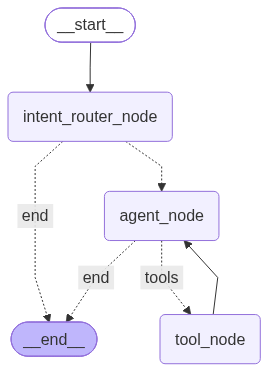

In [51]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [52]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

In [ ]:
result = graph.invoke(initial_state)

In [ ]:
result

In [ ]:
print(result["messages"][-1].content[0]["text"])

### Persistent State

In [53]:
# setup postgres DB
db = os.environ["MULTI_TURN_POSTGRES_DB"]
user = os.environ["MULTI_TURN_POSTGRES_USER"]
password = os.environ["MULTI_TURN_POSTGRES_PASSWORD"]
HOST = "localhost"
PORT = "5432"

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    checkpointer.setup()

### Multiturn Conversation

In [63]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "00000000004"
    }
}

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    result = graph.invoke(initial_state, config)

In [64]:
print(result["messages"][-1].content[0]["text"])

Yes — I found some available products that fit each need:

- For your kid: there’s a **kids tablet case** for the **Fire HD 8 / Fire HD 8 Plus Kids Tablet**. It’s shockproof, lightweight, and has a built-in kickstand for hands-free viewing.  
- For your wife: I found a **smart watch for women** that can receive/dial calls, track fitness, and is **waterproof**.  
- For your pool party: there’s an **IPX7 waterproof Bluetooth speaker** with **30W sound** and long battery life, suitable for outdoor and pool use.

If you want, I can also help narrow these down by budget or style preferences.


In [65]:
initial_state_2 = {
    "messages": [HumanMessage(content="Ah that bluetooth speaker sounds good, which brands are available?")],
    "iteration": 0,
    "final_answer": False
}

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    result = graph.invoke(initial_state_2, config)

In [66]:
result

{'messages': [HumanMessage(content='Can I get a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"tablet for kids child tablet family educational tablet", "k":5}', 'call_id': 'call_RyrGgXxd9EJ8OjQVuC8Up9yz', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a5f12bde9a881a38a36e91b2a2b23d1', 'status': 'completed'}, {'arguments': '{"query":"women\'s watch watch for wife smartwatch elegant watch", "k":5}', 'call_id': 'call_t3UurHW11E3yLx8KbeX4lr1d', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c597ef43006a5f12bde9b881a3a962000af597d1c7', 'status': 'completed'}, {'arguments': '{"query":"waterproof speaker pool party bluetooth speaker outdoor waterproof", "k":5}', 'call_id': 'call_QGVvwHsqBGlRLoPRRh0UylJG', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_00a326a3c59

In [67]:
print(result["messages"][-1].content[0]["text"])

The available products I found for the waterproof Bluetooth speaker are from **Raymate**.

- **Raymate Bluetooth Speakers** — 4.7 rating, **30W IPX7 waterproof**, portable, and made for **home, outdoor, and party** use.

If you want, I can also look for more speaker brand options, but this is the main one I found in the available products.
